In [10]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Danso Emmanuel Effah\OneDrive\Desktop\DATA ANALYSIS\Projects\India Project\Stock Prices Data Set.csv")

print(df.head())
print(df.columns)

  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391
Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [12]:
target = "close"

X = df.drop([target, "date"], axis=1)  # remove Date
y = df[target]

In [14]:
### Splitting tthe data set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# Check columns with text values
print(X_train.select_dtypes(include='object').columns)

Index(['symbol'], dtype='object')


In [17]:
# Convert categorical/text columns into numeric dummy variables
X = pd.get_dummies(X, drop_first=True)

# Split again after encoding
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load data
df = pd.read_csv(r"C:\Users\Danso Emmanuel Effah\OneDrive\Desktop\DATA ANALYSIS\Projects\India Project\Stock Prices Data Set.csv")

# Check missing values
print(df.isnull().sum())

# Remove rows where target is missing
df = df.dropna(subset=["close"])

# Define target
target = "close"
X = df.drop([target, "date"], axis=1)
y = df[target]

# Convert text columns to numbers
X = pd.get_dummies(X, drop_first=True)

# Fill missing values in X
X = X.fillna(X.mean(numeric_only=True))

###Spliting 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

####Training th model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

###Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64
MSE: 0.5285127303391906
R2 Score: 0.9999490192055361


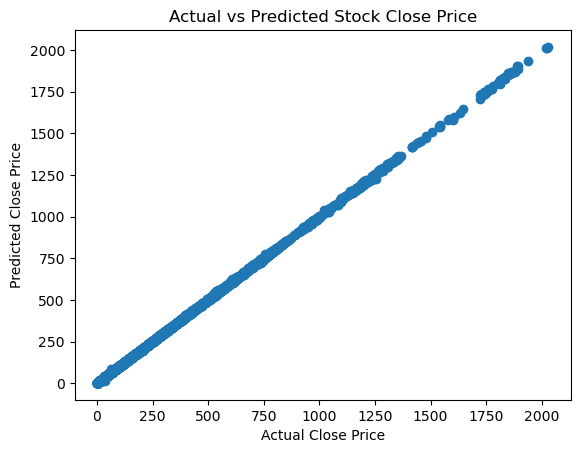

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Stock Close Price")
plt.show()